# Parcial de Aprendizaje Automático

## Alumno: Alderete Tomás


### Información General:

Este dataset proviene del Repositorio de Aprendizaje Automático de la Universidad de California, Irvine

### Dataset:

El dataset consta de información de pacientes egipcios que se sometieron a tratamientos con dosis para la VHC durante aproximadamente 18 meses.

### Columnas: 23

### Registros: 1385


### Información del Paciente:
- Edad
- Género
- IMC



### Síntomas:
- Fiebre
- Vomitos
- Dolor_Cabeza
- Diarrea
- Fatiga y Dolor de Huesos
- Ictericia
- Dolor de Abdomen

### Análisis, Estudios Médicos:

- Globulos Blancos               
- Globulos Rojos                 
- Hemoglobina                    
- Plaquetas                      
- Alamina_Aminotransferasa       
- ALT_Semana4                    
- ALT_Semana12                   
- ALT_Semana24                   
- ALT_Semana36                   
- ALT_Semana48                   
- RNA_Base                       
- RNA_Semana4                    
- RNA_Semana12                   

### Glosario:

- Globulos Blancos: Células del sistema inmunológico que defienden al cuerpo contra infecciones, virus y bacterias.

- Globulos Rojos: Células que transportan oxígeno desde los pulmones a todo el cuerpo y devuelven dióxido de carbono a los pulmones para ser exhalado

- Alamina Aminotransferesa (ALT): Es una enzima presente principalmente en el hígado. Niveles altos en sangre suelen indicar daño o inflamación hepática

- Ácido Ribonucleico (RNA): Molécula esencial que actúa como mensajero entre el ADN y la producción de proteínas. Nota: En análisis de sangre, a veces se confunde con la abreviatura de ARN, pero si te refieres a un marcador de laboratorio, podría ser un error tipográfico por RDW (ancho de distribución de glóbulos rojos) o RBC (recuento de glóbulos rojos), ya que el RNA no es un valor estándar en hemogramas comunes.

- Hemoglobina: Proteína dentro de los glóbulos rojos que contiene hierro y es la responsable de unirse al oxígeno y transportarlo por el cuerpo.

- Plaquetas (Trombocitos): Fragmentos celulares encargados de la coagulación de la sangre y la formación de coágulos para detener hemorragias.


Objetivos

1. (Clasificación) Predecir si un paciente recién ingresado, tiene el sintoma de Ictericia.

2. (Clasificación) Predecir si un paciente en la Semana 12 de sus análisis está curado.

3. (Clasificación) Predecir si un paciente en la Semana 12 está curado, con la información del dataset completo.







## Modelos de Aprendizaje Automático a utilizar: Árbol de Decisión



## Librerías a Usar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score


## Analisis Exploratorio de Datos


### Dataset

In [2]:
dat_csv = pd.read_csv ("HCV-Egy-Data.csv", encoding='ISO-8859-1' )
dat_csv.head()

,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
0,56,1,35,2,1,1,1,2,2,2,...,5,5,5,655330,634536,288194,5,5,13,2
1,46,1,29,1,2,2,1,2,2,1,...,57,123,44,40620,538635,637056,336804,31085,4,2
2,57,1,33,2,2,2,2,1,1,1,...,5,5,5,571148,661346,5,735945,558829,4,4
3,49,2,33,1,2,1,2,1,2,1,...,48,77,33,1041941,449939,585688,744463,582301,10,3
4,59,1,32,1,1,2,1,2,2,2,...,94,90,30,660410,738756,3731527,338946,242861,11,1


### Tipos de Datos

In [3]:
# Inspeccionar los tipos de datos
print(dat_csv.dtypes)

Age                                   int64
Gender                                int64
BMI                                   int64
Fever                                 int64
Nausea/Vomting                        int64
Headache                              int64
Diarrhea                              int64
Fatigue & generalized bone ache       int64
Jaundice                              int64
Epigastric pain                       int64
WBC                                   int64
RBC                                 float64
HGB                                   int64
Plat                                float64
AST 1                                 int64
ALT 1                                 int64
ALT4                                float64
ALT 12                                int64
ALT 24                                int64
ALT 36                                int64
ALT 48                                int64
ALT after 24 w                        int64
RNA Base                        

Matriz de Correlación

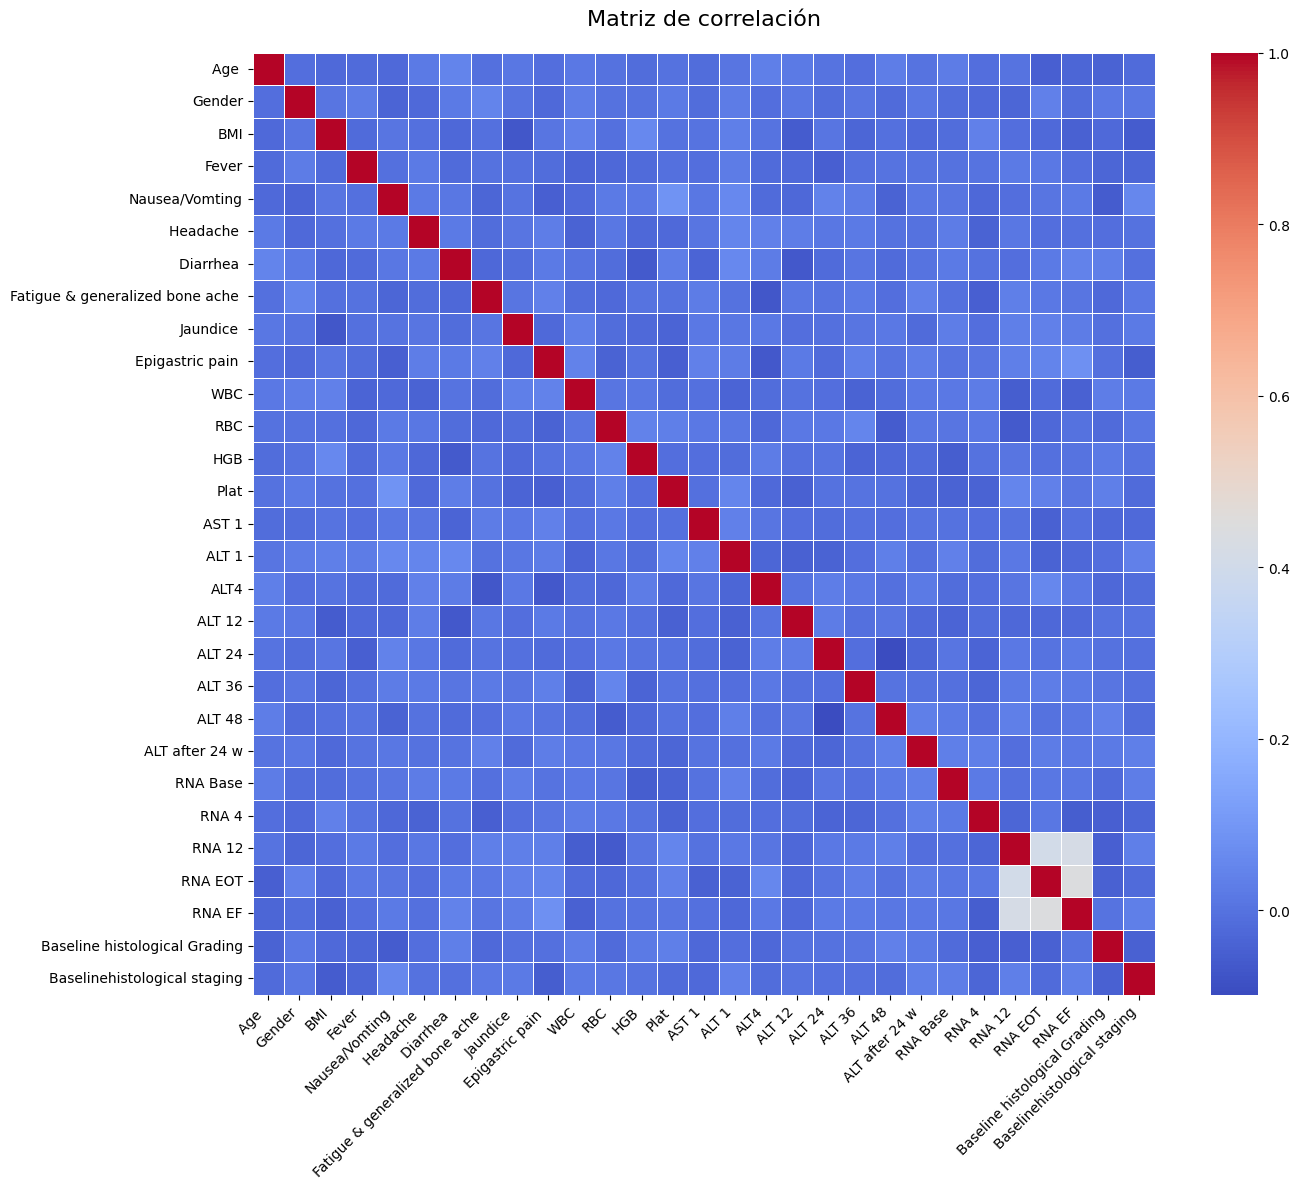

In [4]:
# Correlación del Dataset
corr_matrix = dat_csv.corr()

# Tamaño en pulgadas
fig, ax = plt.subplots(figsize=(14, 12))

# sns.heatmap
sns.heatmap(corr_matrix,
            cmap="coolwarm",
            ax=ax,
            cbar=True,
            linewidths=.5)

plt.xticks(rotation=45, ha='right') # Rotar etiquetas
plt.yticks(rotation=0)
plt.title("Matriz de correlación", pad=20, fontsize=16)
plt.tight_layout()
plt.show()


### Resultado:

Como podemos ver, la mayoría de datos son enteros, algunos flotantes, voy a cambiar algunas de las columnas y transformarlos en tipo bool o modificar su salida, así como genero tiene de salida "1 y 2" siendo 1: Hombre, 2: Mujer. También voy a cambiar el nombre de las columnas y por ultimo eliminar las que no necesite para este estudio.

### Cambio de Nombres de las columnas:

In [5]:
# Traducción al Español
español = ['Edad', 'Genero', 'IMC', 'Fiebre', 'Vomitos', 'Dolor_Cabeza', 'Diarrea', 'Fatiga_y_Dolor_Huesos', 'Ictericia', 'Dolor_Abdomen', 'Globulos_Blancos', 'Globulos_Rojos', 'Hemoglobina', 'Plaquetas', 'Aspartato_Aminotransferasa', 'Alamina_Aminotransferasa', 'ALT_Semana4', 'ALT_Semana12', 'ALT_Semana24', 'ALT_Semana36', 'ALT_Semana48', 'ALT_Semana_post24', 'RNA_Base', 'RNA_Semana4', 'RNA_Semana12', 'RNA_Final_Tratamiento', 'RNA_en_Finalización', 'Gradacion_Histologica_Basal', 'Estadificacion_Histologica_Basal']

df_español = dat_csv.rename(columns=dict(zip(dat_csv.columns, español)))
df_español.head()

# Descarto las columnas que no son necesarias
df_limpio =  df_español[["Edad", "Genero", "IMC", "Fiebre", "Vomitos", "Dolor_Cabeza", "Diarrea", "Fatiga_y_Dolor_Huesos", "Ictericia", "Dolor_Abdomen", "Globulos_Blancos", "Globulos_Rojos", "Hemoglobina", "Plaquetas", "Alamina_Aminotransferasa", "ALT_Semana4", "ALT_Semana12", "ALT_Semana24", "ALT_Semana36", "ALT_Semana48", "RNA_Base", "RNA_Semana4", "RNA_Semana12"]]

# Resultado en español y limpio
df_limpio.head()


,Edad,Genero,IMC,Fiebre,Vomitos,Dolor_Cabeza,Diarrea,Fatiga_y_Dolor_Huesos,Ictericia,Dolor_Abdomen,...,Plaquetas,Alamina_Aminotransferasa,ALT_Semana4,ALT_Semana12,ALT_Semana24,ALT_Semana36,ALT_Semana48,RNA_Base,RNA_Semana4,RNA_Semana12
0,56,1,35,2,1,1,1,2,2,2,...,112132.0,84,52.0,109,81,5,5,655330,634536,288194
1,46,1,29,1,2,2,1,2,2,1,...,129367.0,123,95.0,75,113,57,123,40620,538635,637056
2,57,1,33,2,2,2,2,1,1,1,...,151522.0,49,95.0,107,116,5,5,571148,661346,5
3,49,2,33,1,2,1,2,1,2,1,...,146457.0,64,109.0,80,88,48,77,1041941,449939,585688
4,59,1,32,1,1,2,1,2,2,2,...,187684.0,104,67.0,48,120,94,90,660410,738756,3731527


### Transformar los tipos de datos

In [6]:
# Para evitar un error de Python hago una copia independiente del propio df_Limpio
if not isinstance(df_limpio, pd.DataFrame) or df_limpio._is_copy:
    df_limpio = df_limpio.copy()

# 1. Cambio de Género a tipo Categórico
df_limpio['Genero'] = df_limpio['Genero'].replace({1: 'Hombre', 2: 'Mujer'}).astype('category')

# 2. Cambios a tipo Bool (Sí/No -> True/False)
# 1=False (No), 2=True (Sí)

bool_mapping = {1: False, 2: True}
columnas_bool = [
    'Fiebre',
    'Vomitos',
    'Dolor_Cabeza',
    'Diarrea',
    'Fatiga_y_Dolor_Huesos',
    'Ictericia',
    'Dolor_Abdomen'
]

for col in columnas_bool:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].replace(bool_mapping).astype('boolean')

# 3. Cambios a tipo Entero (Redondeo)
columnas_int = ['Plaquetas', 'ALT_Semana4', 'Globulos_Rojos']

for col in columnas_int:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].round().astype('int64')

# Verificar los cambios
print("Tipos de datos actualizados:")
print(df_limpio.dtypes)
print("\nPrimeras filas:")
df_limpio.head()

Tipos de datos actualizados:
Edad                           int64
Genero                      category
IMC                            int64
Fiebre                       boolean
Vomitos                      boolean
Dolor_Cabeza                 boolean
Diarrea                      boolean
Fatiga_y_Dolor_Huesos        boolean
Ictericia                    boolean
Dolor_Abdomen                boolean
Globulos_Blancos               int64
Globulos_Rojos                 int64
Hemoglobina                    int64
Plaquetas                      int64
Alamina_Aminotransferasa       int64
ALT_Semana4                    int64
ALT_Semana12                   int64
ALT_Semana24                   int64
ALT_Semana36                   int64
ALT_Semana48                   int64
RNA_Base                       int64
RNA_Semana4                    int64
RNA_Semana12                   int64
dtype: object

Primeras filas:


/tmp/ipykernel_55806/515627800.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_limpio[col] = df_limpio[col].replace(bool_mapping).astype('boolean')


,Edad,Genero,IMC,Fiebre,Vomitos,Dolor_Cabeza,Diarrea,Fatiga_y_Dolor_Huesos,Ictericia,Dolor_Abdomen,...,Plaquetas,Alamina_Aminotransferasa,ALT_Semana4,ALT_Semana12,ALT_Semana24,ALT_Semana36,ALT_Semana48,RNA_Base,RNA_Semana4,RNA_Semana12
0,56,Hombre,35,True,False,False,False,True,True,True,...,112132,84,52,109,81,5,5,655330,634536,288194
1,46,Hombre,29,False,True,True,False,True,True,False,...,129367,123,95,75,113,57,123,40620,538635,637056
2,57,Hombre,33,True,True,True,True,False,False,False,...,151522,49,95,107,116,5,5,571148,661346,5
3,49,Mujer,33,False,True,False,True,False,True,False,...,146457,64,109,80,88,48,77,1041941,449939,585688
4,59,Hombre,32,False,False,True,False,True,True,True,...,187684,104,67,48,120,94,90,660410,738756,3731527


### NULOS


In [7]:
conteo_nulos = df_limpio.isnull().sum()
print(conteo_nulos)

Edad                        0
Genero                      0
IMC                         0
Fiebre                      0
Vomitos                     0
Dolor_Cabeza                0
Diarrea                     0
Fatiga_y_Dolor_Huesos       0
Ictericia                   0
Dolor_Abdomen               0
Globulos_Blancos            0
Globulos_Rojos              0
Hemoglobina                 0
Plaquetas                   0
Alamina_Aminotransferasa    0
ALT_Semana4                 0
ALT_Semana12                0
ALT_Semana24                0
ALT_Semana36                0
ALT_Semana48                0
RNA_Base                    0
RNA_Semana4                 0
RNA_Semana12                0
dtype: int64


Luego de realizar el estudio de datos, el siguiente paso es realizar los modelos de aprendizaje, y visualizaciones respectivas para al final llegar  conclusiones.




## EDA:

## Análisis Univariado




### Distribución de Edad

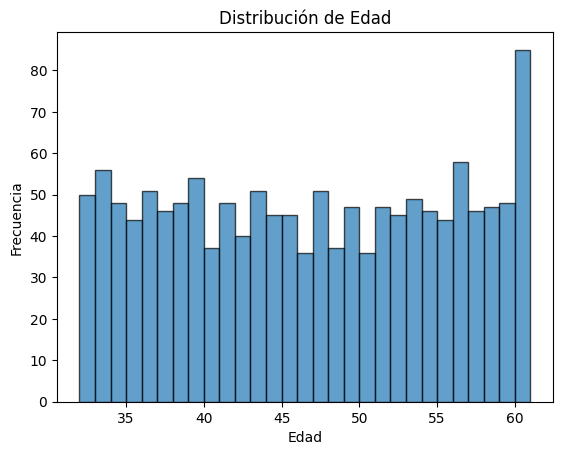

Edad mínima: 32
Edad máxima: 61


In [8]:
plt.hist(df_limpio['Edad'], bins=29, alpha=0.7, edgecolor='k')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edad')
plt.show()

# Minimo de Edad y Máximo
min_edad = df_limpio['Edad'].min()
max_edad = df_limpio['Edad'].max()

print(f"Edad mínima: {min_edad}")
print(f"Edad máxima: {max_edad}")

### Distribución de los datos según el género del paciente

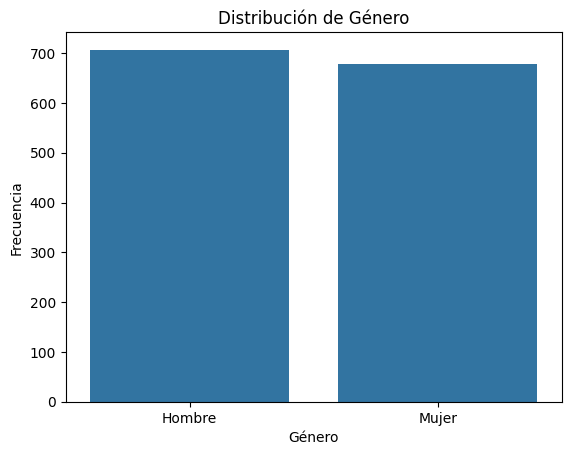

Genero
Hombre    707
Mujer     678
Name: count, dtype: int64


In [9]:
sns.countplot(x='Genero', data=df_limpio)
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.title('Distribución de Género')
plt.show()

print(df_limpio['Genero'].value_counts())

### BoxPlot de RNA

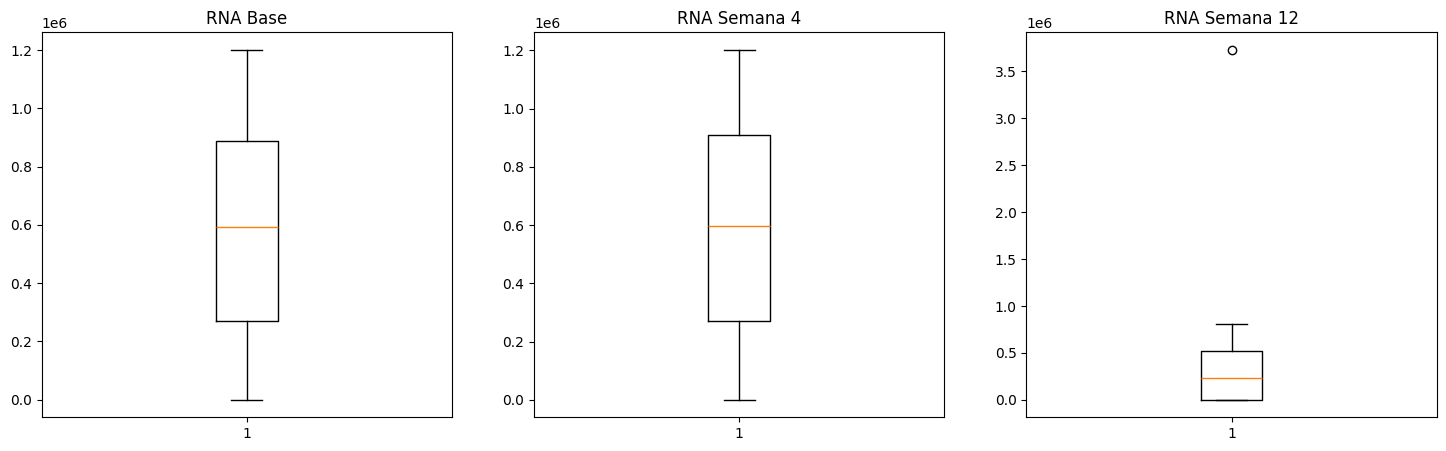

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].boxplot(df_limpio['RNA_Base'])
ax[0].set_title("RNA Base")

ax[1].boxplot(df_limpio['RNA_Semana4'])
ax[1].set_title("RNA Semana 4")

ax[2].boxplot(df_limpio['RNA_Semana12'])
ax[2].set_title("RNA Semana 12")


plt.show()

### BoxPlot de ALT

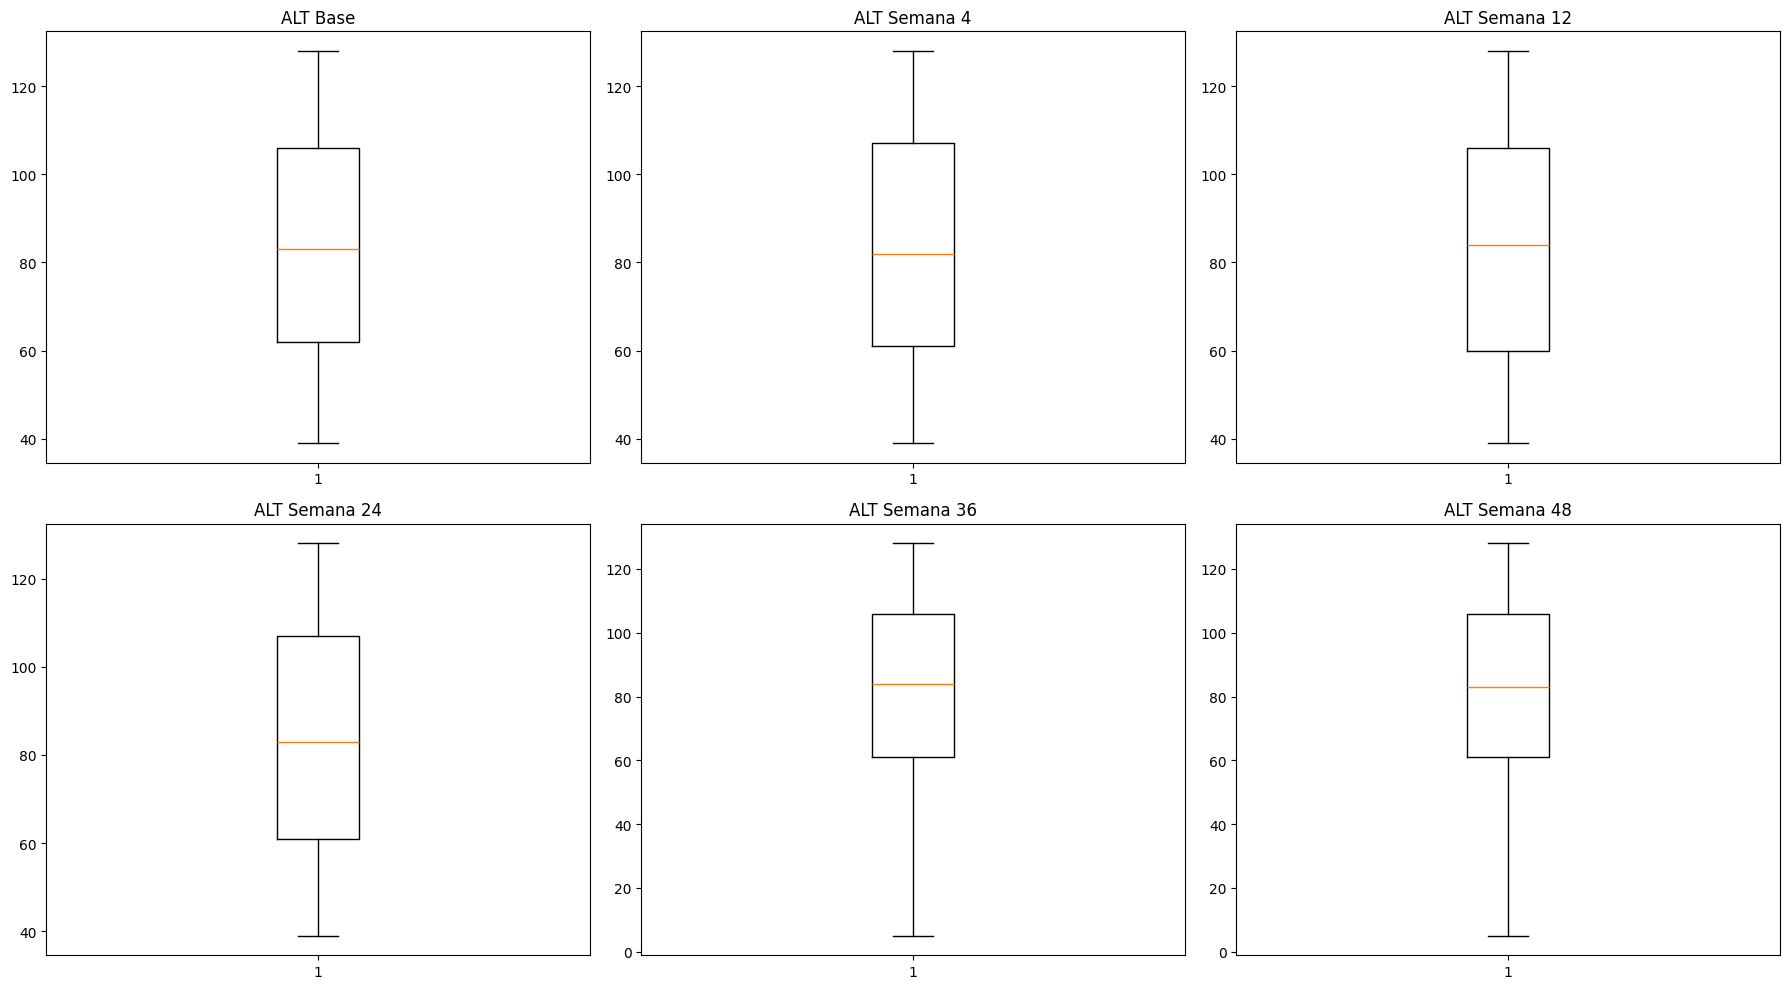

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].boxplot(df_limpio['Alamina_Aminotransferasa'])
ax[0, 0].set_title("ALT Base")

ax[0, 1].boxplot(df_limpio['ALT_Semana4'])
ax[0, 1].set_title("ALT Semana 4")

ax[0, 2].boxplot(df_limpio['ALT_Semana12'])
ax[0, 2].set_title("ALT Semana 12")

ax[1, 0].boxplot(df_limpio['ALT_Semana24'])
ax[1, 0].set_title("ALT Semana 24")

ax[1, 1].boxplot(df_limpio['ALT_Semana36'])
ax[1, 1].set_title("ALT Semana 36")

ax[1, 2].boxplot(df_limpio['ALT_Semana48'])
ax[1, 2].set_title("ALT Semana 48")

plt.tight_layout()
plt.show()

In [12]:
# Corr de Ictericia con las demás variables

# Seleccionar solo columnas numéricas para la correlación
numeric_df_limpio = df_limpio.select_dtypes(include=[np.number, 'boolean'])
# Convert boolean columns to int for correlation calculation
for col in numeric_df_limpio.select_dtypes(include='boolean').columns:
    numeric_df_limpio[col] = numeric_df_limpio[col].astype(int)

corr = numeric_df_limpio.corr()
corr_ictericia = corr['Ictericia']
corr_ictericia = corr_ictericia.sort_values(ascending=False)
print(corr_ictericia)

Ictericia                   1.000000
RNA_Semana12                0.033608
Globulos_Blancos            0.030286
RNA_Base                    0.028796
ALT_Semana48                0.016253
ALT_Semana4                 0.015213
Alamina_Aminotransferasa    0.012601
Edad                        0.010285
Dolor_Cabeza                0.007960
Fatiga_y_Dolor_Huesos       0.007947
ALT_Semana36                0.007296
Vomitos                     0.000711
Fiebre                     -0.005124
ALT_Semana24               -0.007831
RNA_Semana4                -0.008940
ALT_Semana12               -0.008993
Globulos_Rojos             -0.012878
Diarrea                    -0.016618
Hemoglobina                -0.025192
Dolor_Abdomen              -0.025289
Plaquetas                  -0.036599
IMC                        -0.071379
Name: Ictericia, dtype: float64


In [13]:
# Min Max mean de ALT_Semana12
print("ALT_Semana12")
print(f"Máximo: {df_limpio['ALT_Semana12'].max()}")
print(f"Mínimo: {df_limpio['ALT_Semana12'].min()}")
print(f"Media: {df_limpio['ALT_Semana12'].mean()}")
print()

#Globulos_Blancos
print("Globulos Blancos")
print(f"Máximo: {df_limpio['Globulos_Blancos'].max()}")
print(f"Mínimo: {df_limpio['Globulos_Blancos'].min()}")
print(f"Media: {df_limpio['Globulos_Blancos'].mean()}")
print()


#Globulos_Rojos
print("Globulos Rojos")
print(f"Máximo: {df_limpio['Globulos_Rojos'].max()}")
print(f"Mínimo: {df_limpio['Globulos_Rojos'].min()}")
print(f"Media: {df_limpio['Globulos_Rojos'].mean()}")
print()

# Hemoglobina
print("Hemoglobina")
print(f"Máximo: {df_limpio['Hemoglobina'].max()}")
print(f"Mínimo: {df_limpio['Hemoglobina'].min()}")
print(f"Media: {df_limpio['Hemoglobina'].mean()}")
print()

#Plaquetas
print("Plaquetas")
print(f"Máximo: {df_limpio['Plaquetas'].max()}")
print(f"Mínimo: {df_limpio['Plaquetas'].min()}")
print(f"Media: {df_limpio['Plaquetas'].mean()}")


ALT_Semana12
Máximo: 128
Mínimo: 39
Media: 83.51046931407942

Globulos Blancos
Máximo: 12101
Mínimo: 2991
Media: 7533.386281588448

Globulos Rojos
Máximo: 5018451
Mínimo: 3816422
Media: 4422129.610830325

Hemoglobina
Máximo: 15
Mínimo: 10
Media: 12.587725631768953

Plaquetas
Máximo: 226464
Mínimo: 93013
Media: 158348.0606498195


## OBJETIVO 1:

Predecir si un paciente recién ingresado, tiene el sintoma de Ictericia

Métricas Árbol de Decisión:
              precision    recall  f1-score   support

         0.0       0.48      0.61      0.54       135
         1.0       0.50      0.38      0.43       142

    accuracy                           0.49       277
   macro avg       0.49      0.49      0.49       277
weighted avg       0.49      0.49      0.48       277

 
 
 
 
Métricas Árbol de Decisión Mejorado:
              precision    recall  f1-score   support

         0.0       0.60      0.16      0.25       135
         1.0       0.53      0.90      0.67       142

    accuracy                           0.54       277
   macro avg       0.56      0.53      0.46       277
weighted avg       0.56      0.54      0.46       277

Accuracy Árbol: 0.49097472924187724
Accuracy Árbol Ajustado: 0.5379061371841155


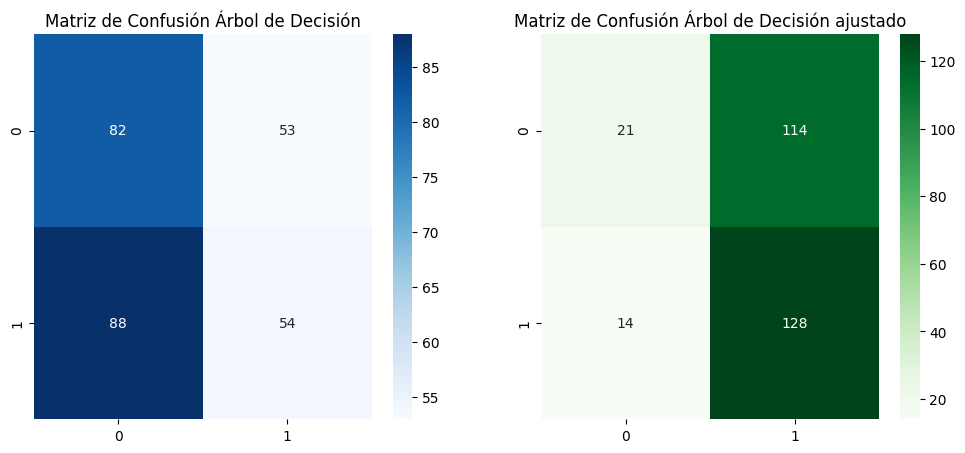

In [14]:
# Copia del dataset
df_Objetivo = df_limpio.copy()

# Quitamos las variables que puedan perjudicar a la predicción de Ictericia
df_Objetivo = df_Objetivo.drop(['Genero', 'Globulos_Blancos', 'IMC', 'Hemoglobina', 'ALT_Semana4', 'ALT_Semana12', 'ALT_Semana36', 'ALT_Semana48', 'RNA_Base', 'RNA_Semana4', 'RNA_Semana12'], axis=1)

# Variable Objetivo a Predecir: Ictericia
X = df_Objetivo.drop('Ictericia', axis=1)
y = df_Objetivo['Ictericia']

# Entrenamiento y Testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creación del Arbol de Decisión
tree = DecisionTreeClassifier(criterion='gini', max_depth=9, min_samples_split=2, min_samples_leaf=2, random_state=42, class_weight='balanced')
tree.fit(X_train, y_train)

# Bajo el umbral o la "vara" para una mejor predicción
probabilidades = tree.predict_proba(X_test)[:, 1]
umbral = 0.4
y_pred_tree = tree.predict(X_test)
y_pred_ajustada = (probabilidades >= umbral).astype(int)

print("Métricas Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))
print(" ")
print(" ")
print(" ")
print(" ")

print("Métricas Árbol de Decisión Mejorado:")
print(classification_report(y_test, y_pred_ajustada))

# Disminuir los Falsos Negativos
print("Accuracy Árbol:", accuracy_score(y_test, y_pred_tree))
print("Accuracy Árbol Ajustado:", accuracy_score(y_test, y_pred_ajustada))


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Matriz de Confusión Árbol de Decisión")

sns.heatmap(confusion_matrix(y_test, y_pred_ajustada), annot=True, fmt="d", ax=ax[1], cmap="Greens")
ax[1].set_title("Matriz de Confusión Árbol de Decisión ajustado")
plt.show()





Mejores parametros de Objetivo 1

In [15]:
parametros_tree = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, None],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4]
}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(),
    param_distributions=parametros_tree,
    n_iter=10,
    cv=5,
    scoring="recall",
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(random_search.best_params_)

print("\nMejor score:")
print(random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados:
{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3, 'criterion': 'gini'}

Mejor score:
0.6429320229320229


## OBJETIVO 1.2:
### Prueba de Modelo en 500 pacientes nuevos aplicando reglas a Ictericia


--- Estadísticas del Dataset Falso ---
Total pacientes: 1500
Pacientes con Ictericia (1): 1094 (72.93%)
Rango ALT: 10 - 799

--- Métricas con Umbral Estándar (0.5) ---
              precision    recall  f1-score   support

           0       0.61      0.69      0.65       131
           1       0.86      0.82      0.84       319

    accuracy                           0.78       450
   macro avg       0.74      0.75      0.74       450
weighted avg       0.79      0.78      0.78       450


--- Métricas con Umbral Bajo (0.3) ---
Recall (Sensibilidad): 0.8652
Precisión: 0.8440
              precision    recall  f1-score   support

           0       0.65      0.61      0.63       131
           1       0.84      0.87      0.85       319

    accuracy                           0.79       450
   macro avg       0.75      0.74      0.74       450
weighted avg       0.79      0.79      0.79       450


--- Importancia de las Variables (Lo que el modelo aprendió) ---
ALT_Base: 0.8366
Edad: 0

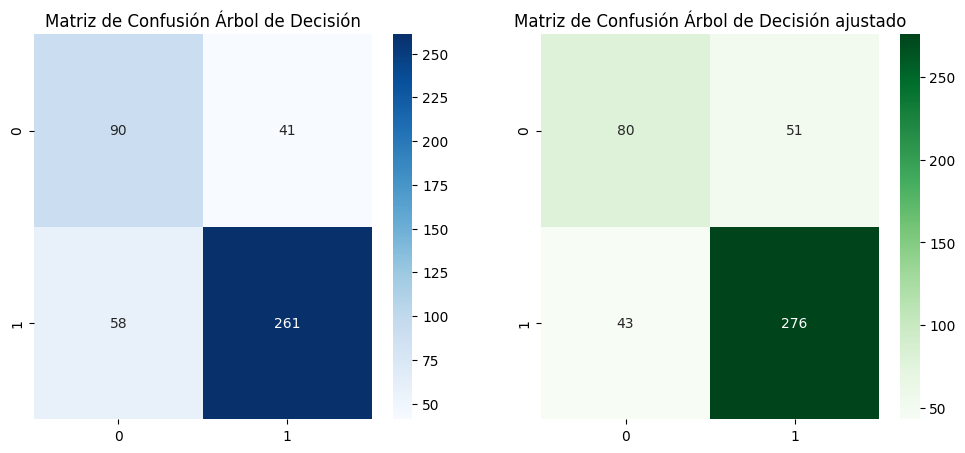

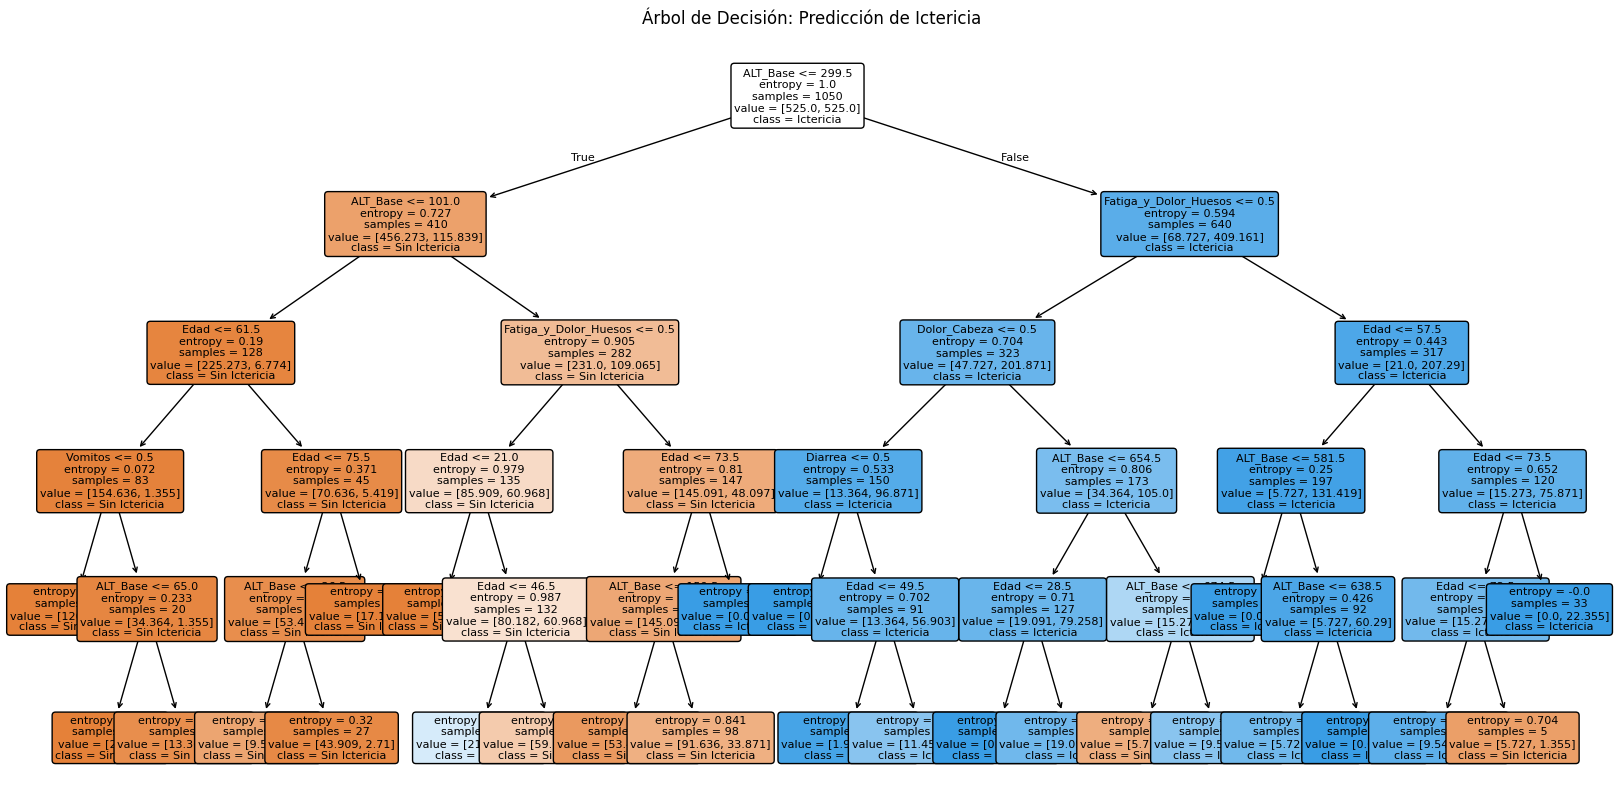

In [16]:
n_pacientes = 1500

# Generamos características aleatorias iniciales
data = {
    'Edad': np.random.randint(18, 80, n_pacientes),
    'Genero': np.random.choice(['M', 'F'], n_pacientes),
    'IMC': np.random.uniform(18, 35, n_pacientes),
    'Fiebre': np.random.choice([0, 1], n_pacientes, p=[0.6, 0.4]), # p = Probabulidad / es decir, 40% tiene fiebre
    'Vomitos': np.random.choice([0, 1], n_pacientes, p=[0.7, 0.3]),
    'Dolor_Cabeza': np.random.choice([0, 1], n_pacientes, p=[0.5, 0.5]),
    'Dolor_Abdomen': np.random.choice([0, 1], n_pacientes, p=[0.5, 0.5]),
    'Fatiga_y_Dolor_Huesos': np.random.choice([0, 1], n_pacientes, p=[0.5, 0.5]),
    'Diarrea': np.random.choice([0, 1], n_pacientes, p=[0.4, 0.6]),
    'Globulos_Blancos': np.random.randint(4, 12, n_pacientes),
    'Plaquetas': np.random.randint(150, 400, n_pacientes),
    'ALT_Base': np.random.randint(10, 800, n_pacientes)
}

df_falso = pd.DataFrame(data)

# REGLAS:
# Regla 1: Si ALT es muy alta (> 300), alta probabilidad de ictericia
# Regla 2: Si ALT es alta (> 200) Y hay fiebre, probabilidad media-alta
# Regla 3: Si ALT es alta (> 100) Y hay dolor abdominal, probabilidad media
# Regla 4: Si ALT es normal (< 100), muy baja probabilidad (a menos que haya otros síntomas graves)

y_ict = []

for i in range(n_pacientes):
    alt = df_falso.loc[i, 'ALT_Base']
    fiebre = df_falso.loc[i, 'Fiebre']
    dolor = df_falso.loc[i, 'Dolor_Abdomen']
    vomitos = df_falso.loc[i, 'Vomitos']

    prob = 0.0

    # Reglas de probabilidad
    if alt > 300:
        prob = 0.95                   # 95% ALT es muy alta
    elif alt > 200 and fiebre == 1:
        prob = 0.75                   # 75% ALT es muy alta y tiene fiebre
    elif alt > 100 and dolor == 1:
        prob = 0.60                   # 60% ALT es alta y tiene dolor
    elif alt > 100 and vomitos == 1:
        prob = 0.55                   # 55% ALT es alta y tiene vomitos
    elif alt > 150 and (fiebre == 1 or dolor == 1):
        prob = 0.50                   # 50% ALT es alta y tiene fiebre o dolor
    elif alt > 100:
        prob = 0.30                   # 30%
    else:
        prob = 0.05                   # Muy baja si ALT es normal

    # Convertir probabilidad a binario (0 o 1) con random
    if np.random.random() < prob:
        y_ict.append(1)
    else:
        y_ict.append(0)

# Columna con los datos recopilados
df_falso['Ictericia'] = y_ict

print("--- Estadísticas del Dataset Falso ---")
print(f"Total pacientes: {len(df_falso)}")
print(f"Pacientes con Ictericia (1): {df_falso['Ictericia'].sum()} ({df_falso['Ictericia'].mean():.2%})")
print(f"Rango ALT: {df_falso['ALT_Base'].min()} - {df_falso['ALT_Base'].max()}")

# Elimino las columnas que no son relevantes
columnas_a_eliminar = ['Genero', 'IMC', 'Globulos_Blancos', 'Plaquetas']
df_modelo = df_falso.drop(columns=columnas_a_eliminar)

X2 = df_modelo.drop('Ictericia', axis=1)
y2 = df_modelo['Ictericia']

# Variables de Entrenamiento
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42)

# Entrenamiento del Árbol
tree = DecisionTreeClassifier(criterion='entropy', max_depth=5, max_leaf_nodes = None, min_samples_leaf=1, min_samples_split = 10, random_state=42, class_weight='balanced')
tree.fit(X_train2, y_train2)


# Predicción y Evaluación del Árbol
y_pred_std = tree.predict(X_test2)

print("\n--- Métricas con Umbral Estándar (0.5) ---")
print(classification_report(y_test2, y_pred_std))

# Predicción con umbral bajo (0.3) para maximizar Recall (Objetivo: Minimizar los Falsos Negativos)
probabilidades = tree.predict_proba(X_test2)[:, 1]
umbral_bajo = 0.3
y_pred_low = (probabilidades >= umbral_bajo).astype(int)


print(f"\n--- Métricas con Umbral Bajo ({umbral_bajo}) ---")
print(f"Recall (Sensibilidad): {recall_score(y_test2, y_pred_low):.4f}")
print(f"Precisión: {precision_score(y_test2, y_pred_low):.4f}")
print(classification_report(y_test2, y_pred_low))

# Reglas
print("\n--- Importancia de las Variables (Lo que el modelo aprendió) ---")
importances = tree.feature_importances_
feature_names = X2.columns
sorted_importances = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
for name, score in sorted_importances:
    print(f"{name}: {score:.4f}")


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test2, y_pred_std), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Matriz de Confusión Árbol de Decisión")

sns.heatmap(confusion_matrix(y_test2, y_pred_low), annot=True, fmt="d", ax=ax[1], cmap="Greens")
ax[1].set_title("Matriz de Confusión Árbol de Decisión ajustado")
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X2.columns, class_names=['Sin Ictericia', 'Ictericia'], filled=True, rounded=True, fontsize=8)
plt.title("Árbol de Decisión: Predicción de Ictericia")
plt.show()


Mejores Parametros de Objetivo 1.2


In [17]:
parametros_tree = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, None],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4]
}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(),
    param_distributions=parametros_tree,
    n_iter=10,
    cv=5,
    scoring="recall",
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train2, y_train2)

print("Mejores parámetros encontrados:")
print(random_search.best_params_)

print("\nMejor score:")
print(random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados:
{'min_samples_split': 6, 'min_samples_leaf': 2, 'max_depth': 2, 'criterion': 'entropy'}

Mejor score:
0.9870967741935484


## OBJETIVO 2:

Predecir si un paciente en la Semana 12 de sus análisis tiene un RNA bajo


In [18]:
# Variables numéricas para la correlación
numeric_Objetivo2 = df_limpio.select_dtypes(include=[np.number, 'boolean'])

# Para las demás se convierten en tipo entero
for col in numeric_Objetivo2.select_dtypes(include='boolean').columns:
    numeric_Objetivo2[col] = numeric_Objetivo2[col].astype(int)

corr = numeric_df_limpio.corr()
corr_ictericia = corr['RNA_Semana12']
corr_ictericia = corr_ictericia.sort_values(ascending=False)
print(corr_ictericia)

RNA_Semana12                1.000000
Plaquetas                   0.050038
ALT_Semana48                0.034132
Ictericia                   0.033608
Dolor_Abdomen               0.031316
Fatiga_y_Dolor_Huesos       0.031220
ALT_Semana36                0.020598
Fiebre                      0.019957
Alamina_Aminotransferasa    0.016020
ALT_Semana24                0.015035
Dolor_Cabeza                0.011729
Hemoglobina                 0.008311
ALT_Semana4                 0.005007
Edad                        0.001578
RNA_Base                   -0.004940
IMC                        -0.009190
Vomitos                    -0.011250
Diarrea                    -0.012324
ALT_Semana12               -0.026248
RNA_Semana4                -0.031168
Globulos_Blancos           -0.051714
Globulos_Rojos             -0.061851
Name: RNA_Semana12, dtype: float64



--- Métricas con Umbral Estándar (0.5) ---
              precision    recall  f1-score   support

           0       0.72      0.23      0.35       295
           1       0.29      0.78      0.43       121

    accuracy                           0.39       416
   macro avg       0.50      0.50      0.39       416
weighted avg       0.59      0.39      0.37       416



Text(70.72222222222221, 0.5, 'Real')

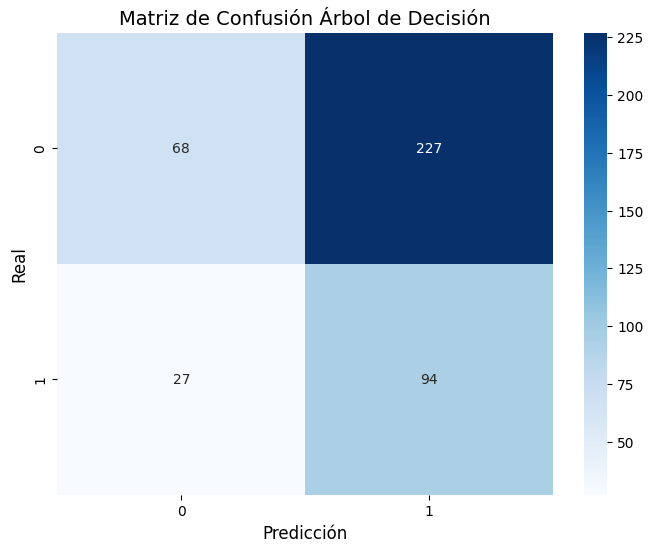

In [19]:
# Copia del DataFrame
df_Objetivo2 = df_limpio.copy()

# Quitamos las variables luego de la semana12
df_Objetivo2 = df_Objetivo2.drop(['ALT_Semana24', 'ALT_Semana36', 'ALT_Semana48'], axis=1)

# Reglas de Curado  a Predecir "Curado" (Curado = 0)
df_Objetivo2['Curado'] = (df_Objetivo2['RNA_Semana12'] <= 15).astype(int)
df_Objetivo2['No_Curado'] = (df_Objetivo2['RNA_Semana12'] > 15).astype(int)


X3 = df_Objetivo2.drop(['Curado', 'No_Curado', 'RNA_Semana12'], axis=1)
y3 = df_Objetivo2['Curado']

# One-hot encode the 'Genero' column
X3 = pd.get_dummies(X3, columns=['Genero'], drop_first=True)

# Entrenamiento y Testeo
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.3, random_state=42)

arbol_curacion = DecisionTreeClassifier(max_depth= None, min_samples_split=8, min_samples_leaf=2, max_leaf_nodes= 5, random_state=42, class_weight='balanced', criterion = 'gini')
arbol_curacion.fit(X_train3, y_train3)


# Predicción y Evaluación del Árbol
y_pred_std3 = arbol_curacion.predict(X_test3)

print("\n--- Métricas con Umbral Estándar (0.5) ---")
print(classification_report(y_test3, y_pred_std3))

# Visualización del Árbol
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test3, y_pred_std3)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matriz de Confusión Árbol de Decisión", fontsize=14)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_ylabel("Real", fontsize=12)


In [20]:
parametros_tree = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, None],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4]
}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(),
    param_distributions=parametros_tree,
    n_iter=10,
    cv=5,
    scoring="recall",
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train3, y_train3)

print("Mejores parámetros encontrados:")
print(random_search.best_params_)

print("\nMejor score:")
print(random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados:
{'min_samples_split': 8, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}

Mejor score:
0.26894049346879534


## OBJETIVO 3:

Predecir si un Paciente se va a curar durante la Semana 12, con la información de todo el dataset.


--- Métricas con Umbral Estándar (0.5) ---
              precision    recall  f1-score   support

           0       0.69      0.50      0.58       295
           1       0.27      0.45      0.34       121

    accuracy                           0.49       416
   macro avg       0.48      0.48      0.46       416
weighted avg       0.57      0.49      0.51       416



Text(70.72222222222221, 0.5, 'Real')

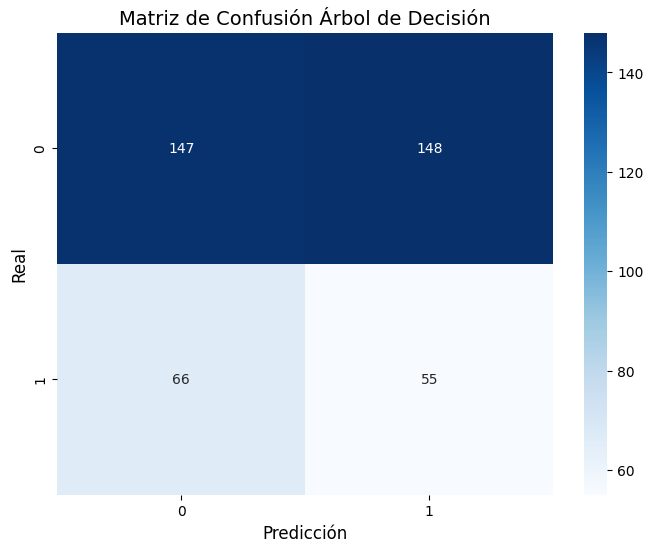

In [21]:
# Copia del DataFrame
df_Objetivo3 = df_limpio.copy()

# Quitamos las variables luego de la semana12
df_Objetivo3 = df_Objetivo3.drop(['Genero'], axis=1)

# Reglas de Curado  a Predecir "Curado" (Curado = 0)
df_Objetivo3['Curado'] = (df_Objetivo3['RNA_Semana12'] <= 15).astype(int)

X4 = df_Objetivo3.drop(['Curado', 'RNA_Semana12', 'ALT_Semana12'], axis=1)
y4 = df_Objetivo3['Curado']

# Entrenamiento y Testeo
X_train4, X_test4, y_train4, y_test4 = train_test_split(X4, y4, test_size=0.3, random_state=42)

arbol_curacion = DecisionTreeClassifier(max_depth=3, min_samples_split=4, min_samples_leaf=2, random_state=42, class_weight='balanced', criterion = 'entropy')
arbol_curacion.fit(X_train4, y_train4)

# Predicción y Evaluación del Árbol
y_pred_std4 = arbol_curacion.predict(X_test4)

print("\n--- Métricas con Umbral Estándar (0.5) ---")
print(classification_report(y_test4, y_pred_std4))

# Visualización del Árbol
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test3, y_pred_std4)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matriz de Confusión Árbol de Decisión", fontsize=14)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_ylabel("Real", fontsize=12)


In [22]:
parametros_tree = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, None],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4]
}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(),
    param_distributions=parametros_tree,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train4, y_train4)

print("Mejores parámetros encontrados:")
print(random_search.best_params_)

print("\nMejor score:")
print(random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados:
{'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 3, 'criterion': 'entropy'}

Mejor score:
0.7192831579509641


Conclusiónes

- **Precision (Precisión):** de los predichos por el modelo como positivos, cuántos lo son realmente.

En el objetivo 1 se puede observar que el modelo decía postivo, y entre un 49 - 53% de los casos esto se cumplía.

En el segundo modelo, aplicando reglas encontramos una mejoría del modelo, empezó a relacionar mucho más los datos ficticios teniendo un 75% de media de acierto

En los casos de enfermos con ictericia, los detecta con mayor facilidad, sin embargo en casos de no enfermos, no es tan simple, se mantiene con un 61%

- **Recall (Sensibilidad):** de los positivos reales, cuántos fueron detectados.

En cuanto al recall, vemos que en ambos casos, en el primer modelo con la "vara", el modelo de aprendizaje detecta con mucha facilidad los enfermos pero tiene muchos problemas para detectar los sanos o curados, encontramos que aquellos pacientes que no tienen Ictericia, en uno de los modelos solamente pudo detectar el 18% de los casos, teniendo una gran cantidad de Falsos Negativos.

Sin embargo en el modelo de Prueba con 500 pacientes aleatorios, aplicando "Reglas", el modelo mejora llegando a 65% o incluso más

Por último, el objetivo principal es evitar los Falsos positivos que en ambos modelos encontramos que superan el 80% de los aciertos, siendo muy pocos de este mismo.

Por qué el interes en evitar esta medida?

Nuestro data set es sobre salud y la misma podemos relacionarla al evento diario de ir a una consulta en el hospital
Un Falso positivo se refiere al evento de un paciente ESTAR ENFERMO y el doctor detectar lo contrario, sería muy peligroso dejar pasar un caso así.

- **F1-score:** media armónica entre precisión y recall.

En el f1-score encontramos una media entre ambas, precisión y recall

- **Accuracy (Exactitud):** proporción de predicciones correctas.

El segundo modelo con las reglas correctas y los datos aleatorios, llegamos a un 80% de precisión, es un gran resultado



Para el Objetivo 2 y 3 respectivamente

Encontramos que los modelos de aprendizaje en su mejor versión aún intentan predecir los datos al azar, incluso "teniendo la información del futuro", esto se debe a la poca relación entre las variables y un evento poco frecuente pero que perjudica al modelo de aprendizaje

Un paciente enfermo puede ingresar con un RNA y un ALT alto y puede en la semana 4 estar "sano" con un RNA y un ALT bajo, seguido de las siguientes semanas volver a presentarse con valores que vuelvan a indicar que está enfermo, no se debe a un mal estudio, sino a un evento médico que el paciente no se terminó de curar.

Entonces los modelos de aprendizaje consiguieron un recall bastante bueno, pero no los utilizaría para una consulta médica ya que su Accuracy en realidad es muy bajo para ello.


Que cambios haría o Mejorías?

Una mejora es la cantidad de datos, también la posibilidad de acceder a información médica como guía, sería muy interesante aplicar "Reglas" como se realizó en el modelo del Objetivo 1.2

Pensé en la posibilidad de usar RandomForest, que es otra manera de estudiar los datos, sin embargo, consideré que es mejor estudiar la información con el Árbol de Decisión.

Por último, me ubiese gustado tener un caso de Regresión, o de agrupamiento, pensé en la posibilidad de agregar un K de 3 siendo 0 -  "Sano" / 1 - "Enfermo" / 2 - "Muy enfermo", pero los datos son muy complicados de estudiarlos, como vimos en los BoxPlot no hay muchas maneras de estudiar este escenario, y en base a diferentes tipos

Por ej:
Puedo basarme en la cantidad de sintomas
Las defensas, es decir, cuanto menor mayor el riesgo
El RNA o el ALT siendo el daño causado por la Hepatitis C.

Pero como sabemos tampoco hay una correlación entre los datos
Siendo esta ultima mi conclusión.



El OBJETIVO con este trabajo era llevarlo a la REALIDAD

Me gustaría plantear esta idea a un Hospital, pero teniendo diferentes reglas, diferente información, sé que soy un estudiante de IA pero podrían mejorarse e incluso con más información podríamos agregar columnas muy útiles

Este trabajo es en escencial de Hepatitis C

Pero la idea es poder identificar diferentes Enfermedades o 1 sola en particular con los diferentes sintomas con la mayor presición posible

En otras palabras mejoraríamos el tiempo de detección y tratamiento de las enfermedades que conocemos.
